# Image Processing Pipeline

End-to-end walkthrough of the `mpdsp` image-processing surface: start from a synthetic image, corrupt it, denoise, take spatial derivatives, detect edges, and clean up with morphology. Every stage of the pipeline is one function call.

Stages covered:

1. Generate a synthetic test image
2. Add Gaussian noise
3. Denoise with a Gaussian blur
4. Take Sobel gradients (Gx, Gy)
5. Gradient magnitude
6. Canny edge detection
7. Morphological cleanup

A second section explores the same pipeline under reduced-precision arithmetic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mpdsp
from mpdsp.image import plot_image, plot_image_grid, plot_pipeline

## 1. Synthetic test image

Combine a few primitive generators to get something with well-defined structure: circle + rectangle + gradient background.

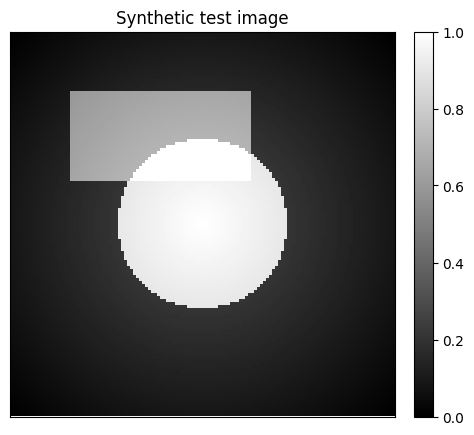

In [2]:
N = 128
background = 0.3 * mpdsp.gradient_radial(N, N, center_val=1.0, edge_val=0.0)
circle = 0.7 * mpdsp.circle(N, N, radius=28)
rect   = 0.5 * mpdsp.rectangle(N, N, y=20, x=20, h=30, w=60)
clean  = np.clip(background + circle + rect, 0.0, 1.0)

plot_image(clean, title='Synthetic test image');

## 2. Corrupt with Gaussian noise

`add_noise` takes the signal stddev directly. SNR drops by about 20 dB at stddev = 0.1 on a [0, 1] image.

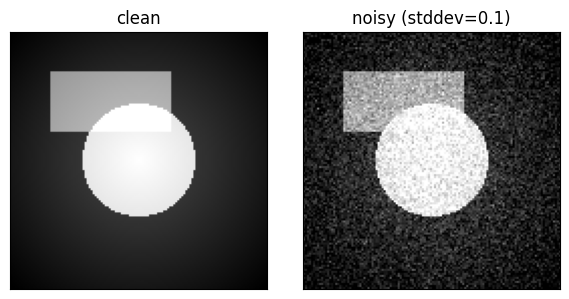

In [3]:
noisy = mpdsp.add_noise(clean, stddev=0.1, seed=42)

plot_image_grid([clean, noisy], titles=['clean', 'noisy (stddev=0.1)'], ncols=2);

## 3. Denoise with a Gaussian blur

Small sigma loses very little detail but leaves speckles; larger sigma cleans the noise at the cost of sharp edges.

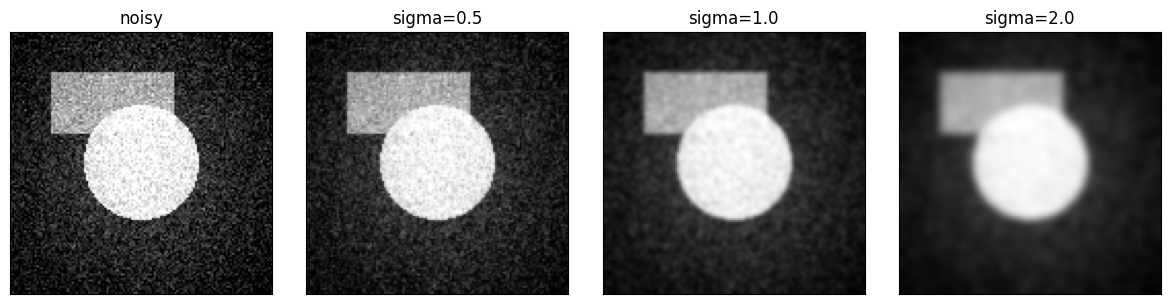

In [4]:
blurred_05 = mpdsp.gaussian_blur(noisy, sigma=0.5)
blurred_10 = mpdsp.gaussian_blur(noisy, sigma=1.0)
blurred_20 = mpdsp.gaussian_blur(noisy, sigma=2.0)

plot_image_grid([noisy, blurred_05, blurred_10, blurred_20],
                titles=['noisy', 'sigma=0.5', 'sigma=1.0', 'sigma=2.0'],
                ncols=4);

## 4–5. Sobel gradients and magnitude

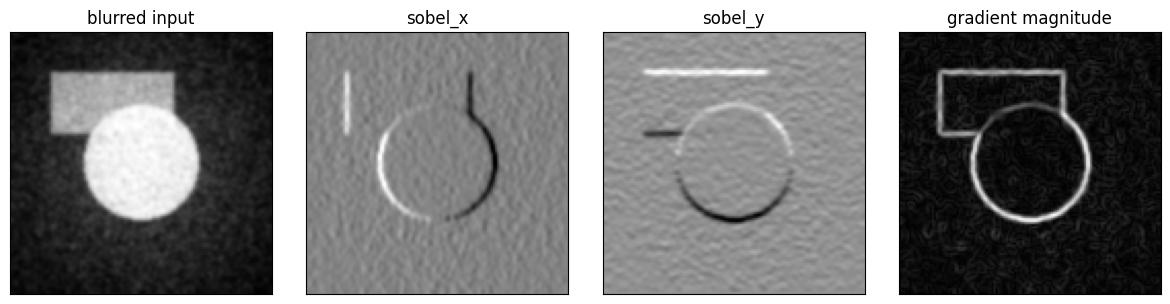

In [5]:
base = blurred_10
gx = mpdsp.sobel_x(base)
gy = mpdsp.sobel_y(base)
gm = mpdsp.gradient_magnitude(gx, gy)

plot_image_grid([base, gx, gy, gm],
                titles=['blurred input', 'sobel_x', 'sobel_y', 'gradient magnitude'],
                ncols=4);

## 6. Canny edge detection

Canny does the blur + gradient + thresholding in one call. Returns a binary edge map (0 or 1 per pixel).

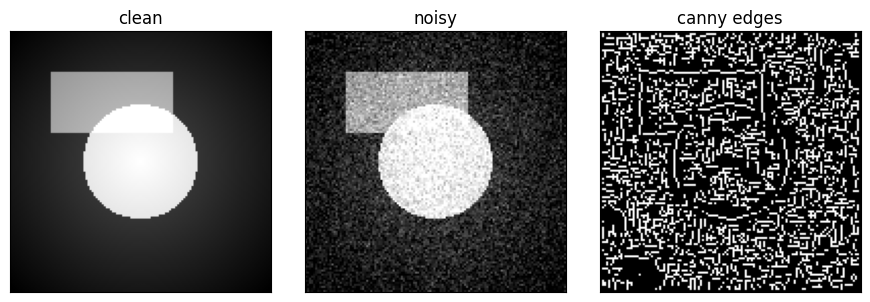

In [6]:
edges = mpdsp.canny(noisy, low_threshold=0.05, high_threshold=0.15, sigma=1.0)

plot_image_grid([clean, noisy, edges],
                titles=['clean', 'noisy', 'canny edges'],
                ncols=3);

## 7. Morphological cleanup

The Canny edge map sometimes picks up spurious short segments from noise. A morphological opening with a small cross element removes isolated pixels; closing fills small gaps along true edges.

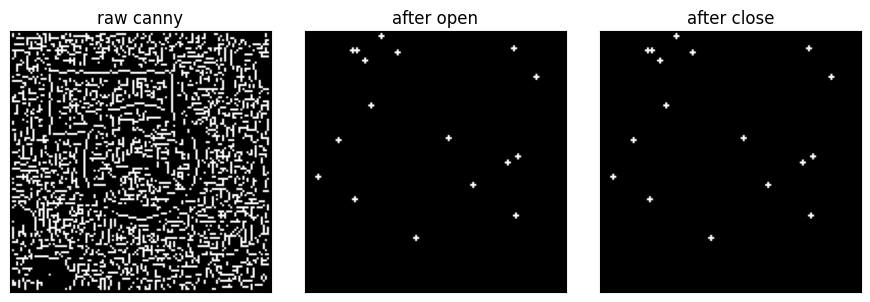

In [7]:
cross = mpdsp.make_cross_element(3)
opened = mpdsp.morphological_open(edges, cross)
closed = mpdsp.morphological_close(opened, cross)

plot_image_grid([edges, opened, closed],
                titles=['raw canny', 'after open', 'after close'], ncols=3);

## Full pipeline in one strip

`plot_pipeline` is the natural helper for laying out the stages above.

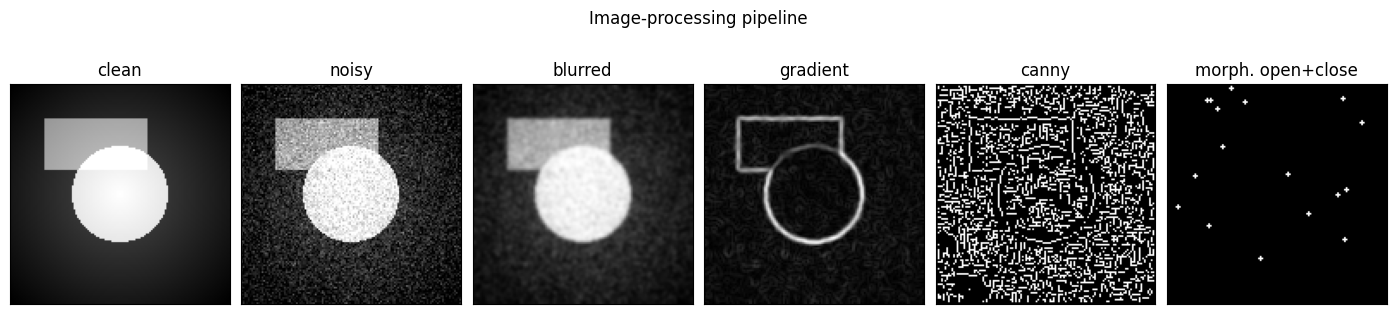

In [8]:
stages = [clean, noisy, blurred_10, gm, edges, closed]
titles = ['clean', 'noisy', 'blurred', 'gradient', 'canny', 'morph. open+close']
fig = plot_pipeline(stages, titles=titles,
                     suptitle='Image-processing pipeline');
fig.set_size_inches(14, 3.5)

## Mixed-precision comparison

Rerun the Gaussian blur step across dtypes and compare against the double-precision reference. This is where image processing meets the core research goal of the package — seeing exactly how much each step's precision matters.

Max deviation from reference (on normalized-[0,1] images):
  reference     : 0.0000e+00
  gpu_baseline  : 3.6796e-08
  half          : 1.8026e-03
  cf24          : 5.6524e-06
  posit_full    : 1.1133e-08
  tiny_posit    : 1.6286e-01


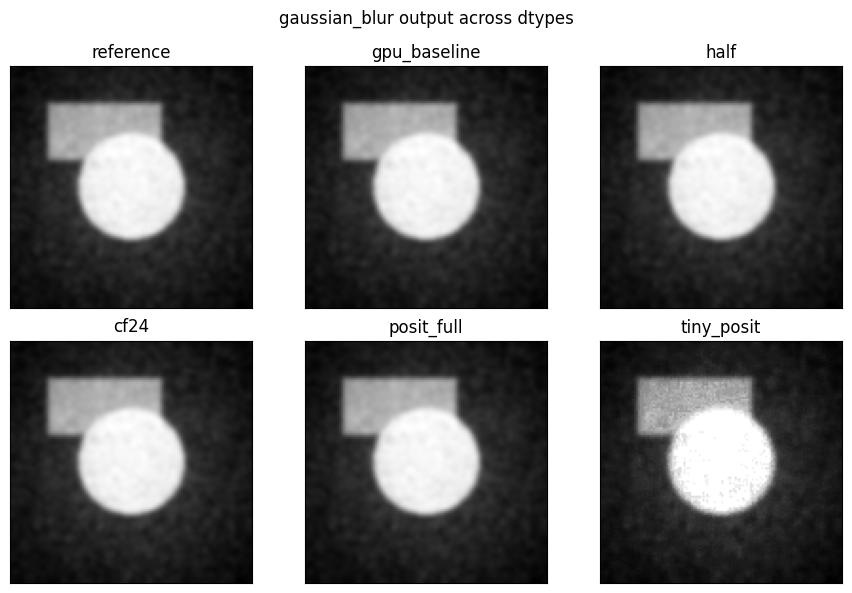

In [9]:
dtypes = ['reference', 'gpu_baseline', 'half', 'cf24', 'posit_full', 'tiny_posit']
outputs = [mpdsp.gaussian_blur(noisy, sigma=1.5, dtype=dt) for dt in dtypes]
ref = outputs[0]

print('Max deviation from reference (on normalized-[0,1] images):')
for dt, out in zip(dtypes, outputs):
    max_dev = np.max(np.abs(out - ref))
    print(f'  {dt:14s}: {max_dev:.4e}')

plot_image_grid(outputs, titles=dtypes, ncols=3,
                 suptitle='gaussian_blur output across dtypes');

## Canny under mixed precision

Canny is a longer pipeline with thresholds, so the precision effect is more pronounced — pixels can flip in or out of the edge set at dtype boundaries.

Pixels where tiny_posit disagrees with reference: 3824 / 16384


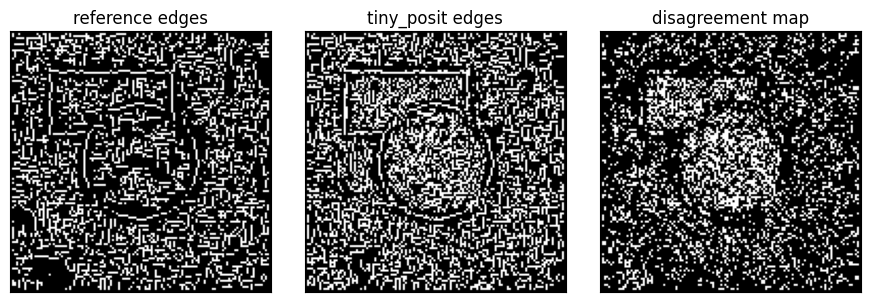

In [10]:
edges_ref = mpdsp.canny(noisy, low_threshold=0.05, high_threshold=0.15, dtype='reference')
edges_tp  = mpdsp.canny(noisy, low_threshold=0.05, high_threshold=0.15, dtype='tiny_posit')

flipped = (edges_ref != edges_tp)
print(f'Pixels where tiny_posit disagrees with reference: {int(flipped.sum())} / {flipped.size}')

plot_image_grid([edges_ref, edges_tp, flipped.astype(float)],
                titles=['reference edges', 'tiny_posit edges', 'disagreement map'],
                ncols=3);

## Takeaways

- The image-processing pipeline is a sequence of NumPy 2D array transformations; every `mpdsp` image function reads and writes float64 at the boundary and dispatches its internal arithmetic on the `dtype` argument.
- **`plot_pipeline` and `plot_image_grid`** make it easy to see stage-by-stage or across dtypes without writing subplot boilerplate each time.
- **Canny is the precision-sensitive stage** in this chain. Gaussian blur barely changes across dtypes; Canny's threshold comparisons mean a few-bit precision drop can flip edge-pixel decisions.
- The morphology ops work on any float image, not just binary edge maps — useful for peak removal, hole filling, and top-hat feature extraction.
- Companion notebook `08_sensor_noise.ipynb` dives into the precision-vs-SQNR trade-off quantitatively.